# 03. toy detection -- 가변 길이 타깃과 N=0 배치

Classification의 target은 스칼라, Segmentation의 target은 고정 `(H, W)`였다. Detection은 이미지당
객체 수(N)가 0개일 수도, 여러 개일 수도 있다 -- target의 shape 자체가 샘플마다 다르다. 이 노트북은
그로 인해 `collate_fn`을 왜 오버라이드해야 하는지, 그리고 N=0인 이미지(객체가 하나도 없는 경우)가
파이프라인을 실제로 통과하는지 확인한다.

In [1]:
import os
import sys


def find_repo_root(start):
    """Walk up from the notebook's own directory to the repository root (identified by the
    presence of `src/`), so `import src...` resolves regardless of where this notebook is run
    from (nbconvert executes with cwd set to the notebook's own directory)."""
    path = os.path.abspath(start)
    while not os.path.isdir(os.path.join(path, "src")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("could not locate repository root (no 'src/' found above cwd)")
        path = parent
    return path


REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# Mirrors src/__main__.py: arm the offline guard before any module that might touch the
# network at import time, then import src.tasks so every @DATASETS/@MODELS/@ADAPTERS/...
# decorator across the 4 tasks (+ toy) actually runs and populates the registries. Until this
# import happens, every Registry in src.core.registry is empty.
from src.core.offline import enable_offline_guard

enable_offline_guard()
import src.tasks  # noqa: F401,E402

print("cwd:", os.getcwd())

import torch

cwd: /mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate


## 데이터 -- `ToyDetDataset`

`src/tasks/toy/dataset.py`는 `num_boxes = idx % 4`로 박스 개수를 인덱스마다 0, 1, 2, 3개로
순환시킨다. 즉 데이터셋 안에 N=0 샘플이 항상 존재하도록 의도적으로 구성되어 있다.

In [2]:
from src.core.registry import DATASETS

train_ds = DATASETS.build("toy_det", root=".", split="train", transform=None,
                           image_size=(64, 64), num_fg_classes=2)

for idx in range(4):
    image, target = train_ds[idx]
    print(f"idx={idx}: image={tuple(image.shape)}  "
          f"boxes={tuple(target['boxes'].shape)}  labels={tuple(target['labels'].shape)}")

idx=0: image=(3, 64, 64)  boxes=(0, 4)  labels=(0,)
idx=1: image=(3, 64, 64)  boxes=(1, 4)  labels=(1,)
idx=2: image=(3, 64, 64)  boxes=(2, 4)  labels=(2,)
idx=3: image=(3, 64, 64)  boxes=(3, 4)  labels=(3,)


`idx=0`의 `boxes`는 `(0, 4)` -- **객체가 없는 이미지**다. `target`은 언제나
`{"boxes": Tensor(N, 4), "labels": Tensor(N,)}` 형태의 dict이지만 N이 0일 수 있다는 것이 이
태스크의 target 규약이다 (`BRIEF.md` §6.1). 박스는 절대 좌표 `xyxy`, 라벨은 1-based(0은 배경
예약)다.

In [3]:
image0, target0 = train_ds[1]
print("boxes (absolute xyxy):", target0["boxes"])
print("labels (1-based, 0=background reserved):", target0["labels"])

boxes (absolute xyxy): tensor([[24., 27., 32., 38.]])
labels (1-based, 0=background reserved): tensor([2])


## `collate_fn`이 list를 유지하는 이유

`torch.utils.data.dataloader.default_collate`는 배치 내 텐서를 `torch.stack`으로 쌓는다 --
동일한 shape를 전제한다. `boxes`의 shape가 샘플마다 `(0, 4)`, `(1, 4)`, `(2, 4)`, ... 로 다르므로
그대로 두면 `stack`이 실패한다. `src/tasks/toy/collate.py`의 `det_collate`는 이미지와 target을
**둘 다 list로 유지**한 채 반환한다 -- 이미지 stack조차 여기서 하지 않는다. 대신
`ToyDetAdapter.train_step`/`eval_step`/`predict_step`이 `torch.stack(images_list, dim=0)`으로
이미지만 필요한 시점에 직접 스택하고, target은 가변 길이 그대로 어댑터 안에서 다룬다 -- "고정 폭으로
패딩"하는 대신 "가변 길이를 list로 보존"하는 쪽을 택한 것이다.

In [4]:
import inspect
from src.tasks.toy.collate import det_collate

print(inspect.getsource(det_collate))

def det_collate(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets



In [5]:
from src.core.registry import ADAPTERS

ToyDetAdapter = ADAPTERS.get("toy_det")
adapter = ToyDetAdapter(loss_fn=None, metrics={}, num_fg_classes=2, stride=8, image_size=(64, 64))
print("adapter.collate_fn():", adapter.collate_fn())

from torch.utils.data import DataLoader

loader = DataLoader(train_ds, batch_size=4, shuffle=False, collate_fn=adapter.collate_fn())
batch_images, batch_targets = next(iter(loader))
print("type(batch_images):", type(batch_images), "-- a Python list of per-image tensors, NOT stacked")
print("len(batch_images):", len(batch_images), " image[0] shape:", batch_images[0].shape)
print("type(batch_targets):", type(batch_targets))
for i, t in enumerate(batch_targets):
    print(f"  sample {i}: boxes={tuple(t['boxes'].shape)} labels={tuple(t['labels'].shape)}")

adapter.collate_fn(): <function det_collate at 0x748c9907add0>
type(batch_images): <class 'list'> -- a Python list of per-image tensors, NOT stacked
len(batch_images): 4  image[0] shape: torch.Size([3, 64, 64])
type(batch_targets): <class 'list'>
  sample 0: boxes=(0, 4) labels=(0,)
  sample 1: boxes=(1, 4) labels=(1,)
  sample 2: boxes=(2, 4) labels=(2,)
  sample 3: boxes=(3, 4) labels=(3,)


## N=0 배치가 실제로 통과하는가

위 첫 배치의 `sample 0`이 이미 N=0이다 (idx=0). `adapter.train_step`과 `adapter.eval_step`에
그대로 통과시켜, 객체가 없는 이미지가 섞여도 예외 없이 loss/예측이 나오는지 직접 확인한다.

In [6]:
assert batch_targets[0]["boxes"].shape[0] == 0, "이 배치의 sample 0은 N=0이어야 한다"

from src.core.registry import LOSSES, MODELS

model = MODELS.build("toy_det_head", num_fg_classes=2)
loss_fn = LOSSES.build("toy_det_loss", num_fg_classes=2, stride=8)
adapter = ToyDetAdapter(loss_fn, {}, num_fg_classes=2, stride=8, image_size=(64, 64))

step_out = adapter.train_step(model, (batch_images, batch_targets), torch.device("cpu"))
print("train_step ok, loss =", float(step_out["loss"]))

model.eval()
with torch.no_grad():
    eval_out = adapter.eval_step(model, (batch_images, batch_targets), torch.device("cpu"))
preds = eval_out["outputs"]["preds"]
print("eval_step ok,", len(preds), "predictions returned (one per image, including the N=0 one)")
print("prediction for the N=0 image -- boxes shape:", preds[0]["boxes"].shape)

train_step ok, loss = 2.3473830223083496
eval_step ok, 4 predictions returned (one per image, including the N=0 one)
prediction for the N=0 image -- boxes shape: torch.Size([3, 4])


N=0 이미지도 다른 이미지와 동일하게 배치의 한 원소로 앞뒤 순서 그대로 처리된다 -- 엔진이나
어댑터 어느 쪽도 "객체가 없으면 건너뛴다"는 특수 분기를 두지 않는다.

## 학습 -- 5 epoch, CPU, mAP 모니터링

`configs/toy/toy_det.yaml`로 처음부터 끝까지 학습시켜, N=0/1/2/3이 섞인 실제 배치들이 5 epoch
내내 문제없이 흘러가는 것을 확인한다.

In [7]:
import os

from src.cli.commands import bind_class_names, build_components, build_dataset, build_transforms
from src.core.builders import build_dataloader, build_optimizer, build_scheduler
from src.core.config import resolve_config, validate_config
from src.core.context import RunContext
from src.core.engine import Trainer
from src.core.logger import MetricsCsvWriter, setup_logger

config = validate_config(resolve_config("configs/toy/toy_det.yaml"))
run_dir = os.path.join("outputs", "notebooks", "03_toy_det")
os.makedirs(run_dir, exist_ok=True)

ctx = RunContext(config, run_dir)
ctx.setup_seed()

transform_train, transform_eval = build_transforms(config)
det_model, det_adapter = build_components(config)
det_adapter.to(ctx.device)
det_train_ds = build_dataset(config, "train", transform_train)
det_valid_ds = build_dataset(config, "valid", transform_eval)
bind_class_names(det_adapter, det_train_ds)

det_train_loader = build_dataloader(det_train_ds, config["data"], "train", det_adapter, ctx.seed,
                                     config["runtime"]["device"])
det_valid_loader = build_dataloader(det_valid_ds, config["data"], "valid", det_adapter, ctx.seed,
                                     config["runtime"]["device"])
det_optimizer = build_optimizer(config["optim"], det_model)
det_scheduler = build_scheduler(config["optim"], det_optimizer)

logger = setup_logger(run_dir, "WARNING")
metrics_writer = MetricsCsvWriter(run_dir, [m["name"] for m in config["metrics"]])
trainer = Trainer(logger=logger, metrics_writer=metrics_writer,
                   checkpoint_dir=os.path.join(run_dir, "checkpoints"))

best = trainer.fit(det_model, det_adapter, det_train_loader, det_valid_loader, det_optimizer,
                    det_scheduler, ctx)
print("best valid mAP:", best)

best valid mAP: 0.0


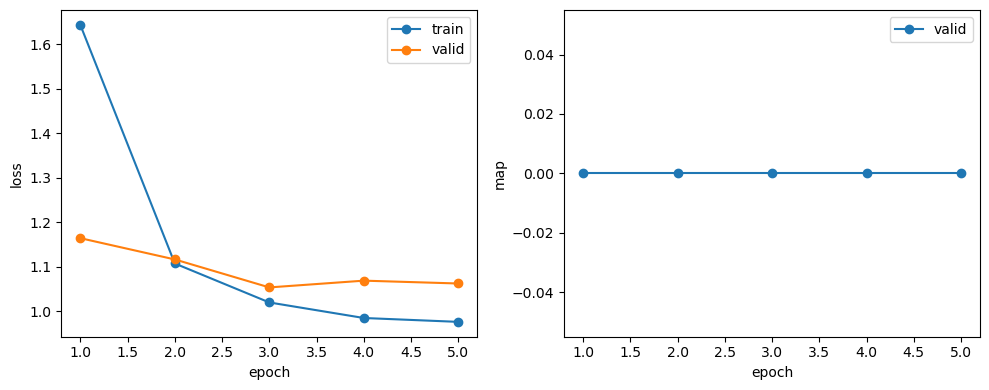

,epoch,split,loss,map,lr,elapsed_sec
0,1,train,1.643682,NaN,0.001000,0.165277
1,1,valid,1.164430,0.0,0.000000,0.053496
2,2,train,1.107512,NaN,0.000905,0.091314
3,2,valid,1.116615,0.0,0.000000,0.041216
4,3,train,1.019970,NaN,0.000658,0.090734
5,3,valid,1.053765,0.0,0.000000,0.037723
6,4,train,0.985043,NaN,0.000352,0.092432
7,4,valid,1.068950,0.0,0.000000,0.038547
8,5,train,0.976347,NaN,0.000105,0.089209
9,5,valid,1.062559,0.0,0.000000,0.037459


In [8]:
from notebooks.common import plot_training_curves

plot_training_curves(os.path.join(run_dir, "metrics_epoch.csv"), ["map"])

## 요약

- Detection의 target은 `{"boxes": (N, 4), "labels": (N,)}`이며 N은 이미지마다 다르다 (0 포함).
  박스는 절대 xyxy, 라벨은 1-based다.
- `default_collate`는 shape가 고정이라는 전제가 깨지므로, `toy_det` 어댑터는 `collate_fn`을
  `det_collate`로 오버라이드해 이미지와 target을 둘 다 list로 유지한다. 이미지 stacking은
  `default_collate`가 아니라 어댑터의 `train_step`/`eval_step`/`predict_step` 내부에서 이루어진다.
- N=0 이미지는 특수 분기 없이 다른 이미지와 동일하게 배치를 통과한다 -- `train_step`/`eval_step`이
  빈 `boxes`/`labels`를 가진 target을 그대로 받아들인다.

다음(`04_toy_anomaly.ipynb`)은 학습 시 target이 아예 비어 있는(`{}`) 경우와, 모델이 자신만의
`train_step`을 정의해 어댑터의 기본 경로를 우회하는 경우를 다룬다.